# Visualization of Model Metrics

This notebook visualizes the evaluation metrics from `metrics_summary.json`, comparing rhythm diversity and repetition ratio across different generated music models (AE and RLHF).

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('default')
sns.set_palette("husl")

In [12]:
# Load metrics data
project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = project_root.parent

metrics_path = project_root / 'outputs' / 'plots' / 'metrics_summary.json'

with open(metrics_path, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['model'] = df['file'].str.split('_').str[0]  # Extract model from filename (ae or rlhf)
df.head()

,file,rhythm_diversity,repetition_ratio,model
0,ae_gen_0.mid,0.007874,0.991935,ae
1,ae_gen_1.mid,0.007874,0.991935,ae
2,ae_gen_2.mid,0.015748,0.983871,ae
3,ae_gen_3.mid,0.007874,0.991935,ae
4,ae_gen_4.mid,0.007874,0.991935,ae


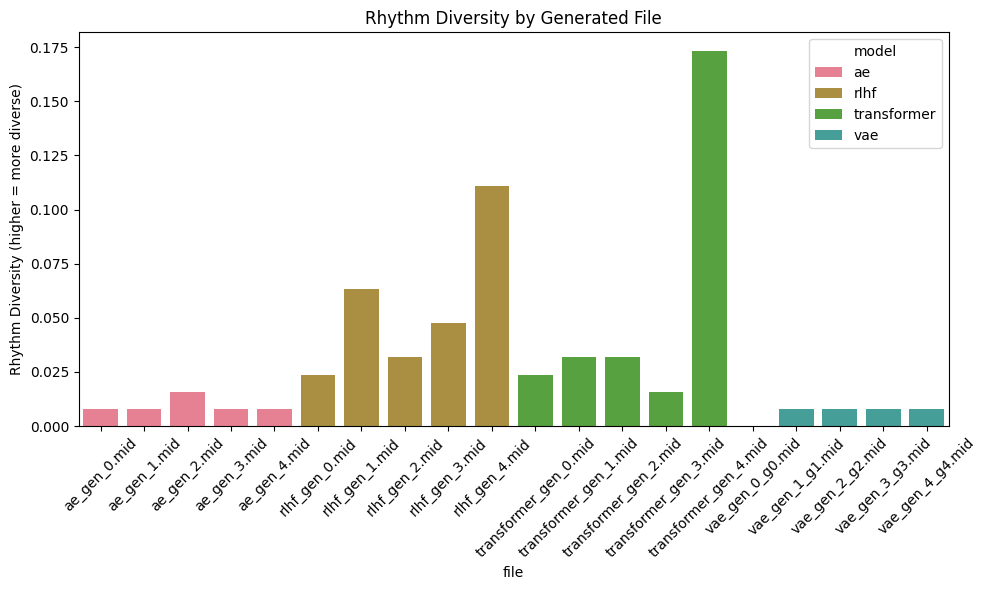

In [13]:
# Bar chart of rhythm diversity by model
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='file', y='rhythm_diversity', hue='model')
plt.xticks(rotation=45)
plt.title('Rhythm Diversity by Generated File')
plt.ylabel('Rhythm Diversity (higher = more diverse)')
plt.tight_layout()
plt.show()

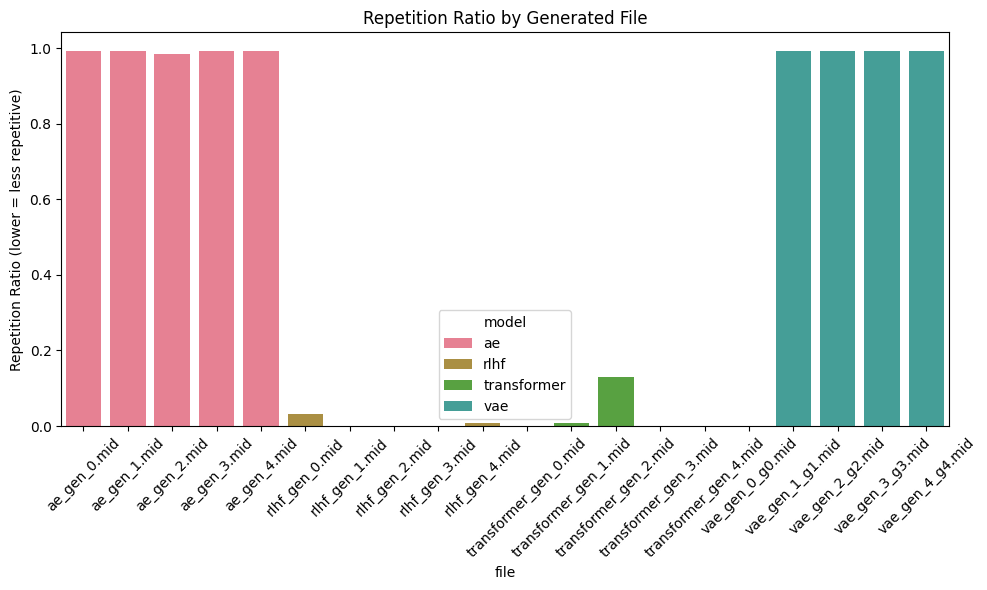

In [15]:
# Bar chart of repetition ratio by model
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='file', y='repetition_ratio', hue='model')
plt.xticks(rotation=45)
plt.title('Repetition Ratio by Generated File')
plt.ylabel('Repetition Ratio (lower = less repetitive)')
plt.tight_layout()
plt.show()

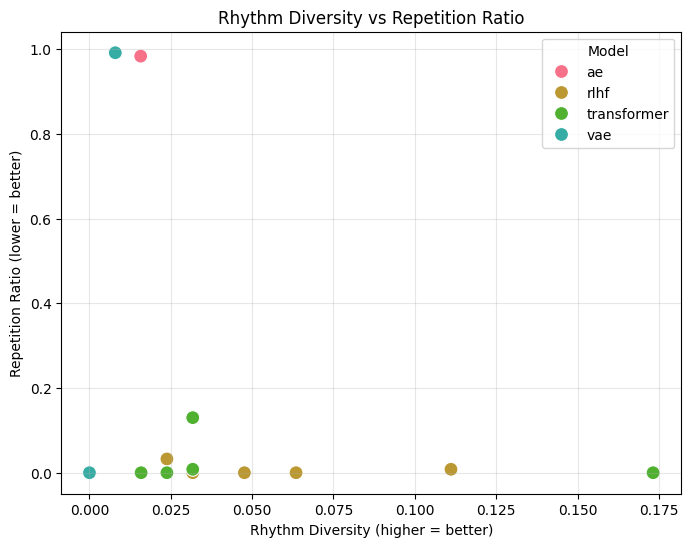

In [8]:
# Scatter plot: Rhythm Diversity vs Repetition Ratio
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='rhythm_diversity', y='repetition_ratio', hue='model', s=100)
plt.title('Rhythm Diversity vs Repetition Ratio')
plt.xlabel('Rhythm Diversity (higher = better)')
plt.ylabel('Repetition Ratio (lower = better)')
plt.legend(title='Model')
plt.grid(True, alpha=0.3)
plt.show()

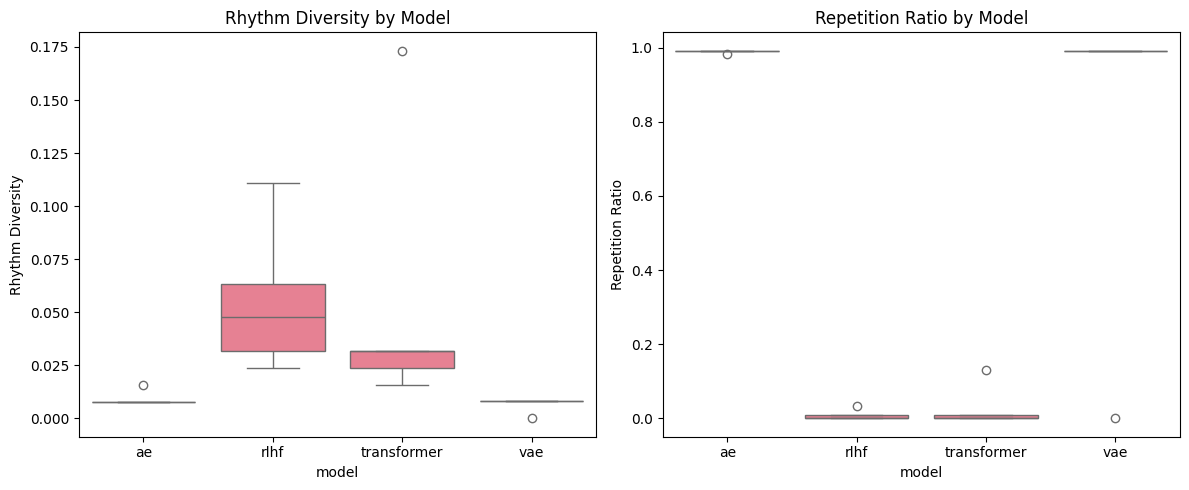

In [9]:
# Box plots comparing models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='model', y='rhythm_diversity', ax=axes[0])
axes[0].set_title('Rhythm Diversity by Model')
axes[0].set_ylabel('Rhythm Diversity')

sns.boxplot(data=df, x='model', y='repetition_ratio', ax=axes[1])
axes[1].set_title('Repetition Ratio by Model')
axes[1].set_ylabel('Repetition Ratio')

plt.tight_layout()
plt.show()

In [10]:
# Summary statistics
print("Summary Statistics by Model:")
summary = df.groupby('model').agg({
    'rhythm_diversity': ['mean', 'std', 'min', 'max'],
    'repetition_ratio': ['mean', 'std', 'min', 'max']
})
print(summary)

Summary Statistics by Model:
            rhythm_diversity                               repetition_ratio  \
                        mean       std       min       max             mean   
model                                                                         
ae                  0.009449  0.003521  0.007874  0.015748         0.990323   
rlhf                0.055556  0.034594  0.023810  0.111111         0.008130   
transformer         0.055281  0.066262  0.015873  0.173228         0.027642   
vae                 0.006349  0.003549  0.000000  0.007937         0.793496   

                                           
                  std       min       max  
model                                      
ae           0.003607  0.983871  0.991935  
rlhf         0.014082  0.000000  0.032520  
transformer  0.057373  0.000000  0.130081  
vae          0.443578  0.000000  0.991870  
